
### 📌 Projet — Optimisation d’une Rfissa (Auteur : Saad Zidani)

**But.** Déterminer les quantités optimales (g/pers) de poulet, lentilles, oignons, msemen, fenugrec et épices pour atteindre des **cibles nutritionnelles** (calories, protéines), respecter des **contraintes culinaires** (bornes, ratio lentilles/poulet, somme d’épices) et **minimiser le coût** (DH/pers).

**Variables (g/pers).** $x_p, x_l, x_o, x_m, x_f, x_g, x_c, x_r, x_s$

**Nutrition**
$$
C(x) = \sum_i x_i\,\frac{\text{kcal}_i}{100}
\qquad
P(x) = \sum_i x_i\,\frac{\text{prot}_i}{100}.
$$

**Coût**
$$
\text{Coût}(x) = \sum_i x_i\,\frac{\text{prix}_i}{1000}\;(\text{DH}).
$$

**Objectif**
$$
\min_x\; w_c(C-C^*)^2 + w_p(P-P^*)^2 + w_t\,\Pi(x) + w_b\,\text{Coût}(x).
$$

**Contraintes**
$$
x_i \in [x_i^{\min}, x_i^{\max}],\quad
0.2 \le \frac{x_l}{x_p} \le 0.6,\quad
x_g + x_c + x_r + x_s \le 6\;\text{g}.
$$

**Méthode :** SLSQP — `scipy.optimize.minimize`.  
**Note :** Valeurs nutritionnelles et prix DH/kg **paramétrables**.



# Optimisation d'une Rfissa : modèle nutritionnel & coût 

Ce notebook modélise la **Rfissa** (poulet, lentilles, oignons, fenugrec/halba, épices, msemen/trid) et **optimise les quantités par personne** pour atteindre des **cibles nutritionnelles** (calories, protéines), respecter des **contraintes culinaires** (ratios, bornes réalistes) et **minimiser le coût**.

## Sources culinaires (composition & quantités usuelles)
- Rfissa traditionnelle : poulet, lentilles, fenugrec (halba), oignons, épices, tride/msemen; ex. 1 poulet, ~250 g lentilles, 1–2 c. s. halba, ~2 gros oignons, 10–12 msemen pour 6 pers. ([Les Trésors du Maroc](https://les-tresors-du-maroc.fr/rfissa-marocaine-recette-poulet-lentilles-halba/)).
- Variantes et pas-à-pas : ([Morocco Taste](https://www.morocco-taste.com/moroccan-chicken-rfissa-recipe-to-love/)), ([Try Arabic Food](https://www.tryarabicfood.com/2025/06/rfissa-traditional-moroccan-chicken-and.html)).

## Sources nutritionnelles (valeurs par 100 g, moyennes)
- **Poulet cuit (blanc sans peau)** ≈ 157 kcal, **32 g protéines**/100 g ([MyFoodData](https://tools.myfooddata.com/nutrition-facts/100009715/100g)).
- **Lentilles cuites** ≈ 116 kcal, **~9 g protéines**/100 g ([Foodstruct – USDA](https://foodstruct.com/food/lentil)).
- **Oignons crus/cuits** ≈ 40–47 kcal, **~1 g protéines**/100 g ([USDA profil](https://selfmadehealth.com/en/ndb/pml/us-11282), [MyFoodData](https://tools.myfooddata.com/nutrition-facts/2710796/100g)).
- **Msemen/Trid** ≈ 330–332 kcal, **~6–8 g protéines**/100 g ([MyFoodData – Homemade](https://tools.myfooddata.com/nutrition-facts/100132505/wt1), [Les-calories.com](https://www.les-calories.com/blog/crepe-marocaine-msemmens)).
- **Fenugrec (graines)** ≈ 323 kcal, **23 g protéines**/100 g (utilisé en petites quantités) ([FatSecret – USDA](https://foods.fatsecret.com/calories-nutrition/usda/fenugreek-seed?portionid=56612&portionamount=100.000)).

> ⚠️ Les valeurs nutritionnelles varient selon la recette, la cuisson et le produit. Ce modèle utilise des moyennes **indicatives** que vous pouvez ajuster ci‑dessous.



## Modèle mathématique

On définit, **par personne**, les variables (en grammes) :

$$
x_p \;\text{(poulet)},\; x_l \;\text{(lentilles)},\; x_o \;\text{(oignons)},\; x_m \;\text{(msemen/trid)},\; x_f \;\text{(fenugrec)},\; x_g \;\text{(gingembre)},\; x_c \;\text{(curcuma)},\; x_r \;\text{(ras el hanout)},\; x_s \;\text{(safran)}.
$$

---

### Les calories et protéines par personne

$$
C(x) = \sum_i x_i \cdot \frac{\text{kcal}_i}{100},\qquad
P(x) = \sum_i x_i \cdot \frac{\text{prot}_i}{100}.
$$

---

### Objectif

$$
\min_x\; \mathcal{L}(x) = w_c\,\big(C(x)-C^*\big)^2 + w_p\,\big(P(x)-P^*\big)^2 + w_t\,\Pi(x) + w_b\,\text{Coût}(x).
$$

avec :

$$
\text{Coût}(x) = \sum_i x_i \cdot \frac{\text{prix}_i}{1000}\;\text{(DH)}.
$$

---

### Contraintes

- Bornes réalistes : $$ x_i \in [\underline{x}_i , \overline{x}_i] $$.
- Ratio texture : $$ 0.2 \le \dfrac{x_l}{x_p} \le 0.6 $$.
- Sommation d'épices : $$ x_g + x_c + x_r + x_s \le 6\;\text{g par personne} $$.

---

Résolution par **SLSQP** : `scipy.optimize.minimize`, sous bornes et contraintes.


In [1]:

from dataclasses import dataclass
from typing import Dict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize



## Paramètres du modèle

- Cibles par personne (par défaut) : $$ C^* = 700\;\text{kcal},\quad P^* = 35\;\text{g} $$.
- Pondérations : $$ (w_c,\; w_p,\; w_t,\; w_b) $$.
- Valeurs nutritionnelles et **prix DH/kg** ajustables.



## Fonction objectif et contraintes (récapitulatif)

Pénalités de goût utilisées :
- Ratio lentilles/poulet souhaité $$[0.2,\,0.6]$$.
- Msemen recommandé $$[80,\,150]$$ g/pers.
- Halba (fenugrec) douce $$\le 8$$ g/pers (cap souple).
- Oignons ciblés $$\approx 75$$ g/pers, flexible.


In [2]:

@dataclass
class Ingredient:
    nom: str
    kcal_per_100g: float
    prot_per_100g: float
    price_dh_per_kg: float
    min_g: float
    max_g: float
    role: str = "principal"

NUTRI_PAR_100G = {
    "poulet": {"kcal": 157.0, "prot": 32.1},
    "lentilles": {"kcal": 116.0, "prot": 9.0},
    "oignons": {"kcal": 42.0, "prot": 1.0},
    "msemen": {"kcal": 330.0, "prot": 7.0},
    "fenugrec": {"kcal": 323.0, "prot": 23.0},
    "gingembre": {"kcal": 335.0, "prot": 9.0},
    "curcuma": {"kcal": 354.0, "prot": 8.0},
    "ras_el_hanout": {"kcal": 300.0, "prot": 10.0},
    "safran": {"kcal": 310.0, "prot": 11.0},
}

PRIX_DH_PAR_KG = {
    "poulet": 24.44,
    "lentilles": 18.0,
    "oignons": 6.0,
    "msemen": 30.0,
    "fenugrec": 60.0,
    "gingembre": 120.0,
    "curcuma": 120.0,
    "ras_el_hanout": 160.0,
    "safran": 30000.0,
}

BORNE_PAR_ING = {
    "poulet": (80.0, 200.0),
    "lentilles": (40.0, 150.0),
    "oignons": (30.0, 120.0),
    "msemen": (50.0, 180.0),
    "fenugrec": (0.0, 12.0),
    "gingembre": (0.5, 2.0),
    "curcuma": (0.5, 2.0),
    "ras_el_hanout": (0.5, 2.0),
    "safran": (0.0, 0.05),
}

INGREDIENTS: Dict[str, Ingredient] = {}
for ing in NUTRI_PAR_100G.keys():
    INGREDIENTS[ing] = Ingredient(
        nom=ing,
        kcal_per_100g=NUTRI_PAR_100G[ing]["kcal"],
        prot_per_100g=NUTRI_PAR_100G[ing]["prot"],
        price_dh_per_kg=PRIX_DH_PAR_KG[ing],
        min_g=BORNE_PAR_ING[ing][0],
        max_g=BORNE_PAR_ING[ing][1],
        role=("epice" if ing in {"fenugrec","gingembre","curcuma","ras_el_hanout","safran"} else "principal")
    )

CAL_TARGET = 700.0
PROT_TARGET = 35.0
W_CAL = 1.0
W_PROT = 1.0
W_TASTE = 0.5
W_COST = 0.002
ORDRE = ["poulet","lentilles","oignons","msemen","fenugrec","gingembre","curcuma","ras_el_hanout","safran"]


In [3]:

def vect_to_dict(x):
    return {ing: float(x[i]) for i, ing in enumerate(ORDRE)}

def calories(x):
    d = vect_to_dict(x)
    return sum(d[k] * INGREDIENTS[k].kcal_per_100g / 100.0 for k in ORDRE)

def proteins(x):
    d = vect_to_dict(x)
    return sum(d[k] * INGREDIENTS[k].prot_per_100g / 100.0 for k in ORDRE)

def cost_dh(x):
    d = vect_to_dict(x)
    return sum(d[k] * INGREDIENTS[k].price_dh_per_kg / 1000.0 for k in ORDRE)

def taste_penalty(x):
    d = vect_to_dict(x)
    poulet = d["poulet"]
    lent = d["lentilles"]
    pen_ratio = 0.0
    if poulet > 0:
        ratio = lent / poulet
        lower, upper = 0.2, 0.6
        if ratio < lower:
            pen_ratio += (lower - ratio)**2 * 50.0
        elif ratio > upper:
            pen_ratio += (ratio - upper)**2 * 50.0
    pen_halba = max(0.0, d["fenugrec"] - 8.0)**2 * 10.0
    pen_msem = 0.0
    if d["msemen"] < 80.0:
        pen_msem += (80.0 - d["msemen"])**2 * 0.05
    if d["msemen"] > 150.0:
        pen_msem += (d["msemen"] - 150.0)**2 * 0.05
    target_o = 75.0
    pen_o = ((d["oignons"] - target_o)/25.0)**2 * 5.0
    return pen_ratio + pen_halba + pen_msem + pen_o

def objective(x):
    cal = calories(x)
    prot = proteins(x)
    return (W_CAL*(cal - CAL_TARGET)**2
            + W_PROT*(prot - PROT_TARGET)**2
            + W_TASTE*taste_penalty(x)
            + W_COST*cost_dh(x))

BOUNDS = [(INGREDIENTS[k].min_g, INGREDIENTS[k].max_g) for k in ORDRE]

def spices_sum(x):
    idx = [ORDRE.index(k) for k in ["gingembre","curcuma","ras_el_hanout","safran"]]
    return sum(x[i] for i in idx)

CONS = ({"type": "ineq", "fun": lambda x: 6.0 - spices_sum(x)},)



## Résolution SLSQP
Point de départ : valeurs moyennes; puis optimisation sous bornes et contrainte d'épices.


In [4]:

x0 = np.array([120, 80, 70, 120, 6, 1.0, 1.0, 1.0, 0.02], dtype=float)
res = minimize(objective, x0, method="SLSQP", bounds=BOUNDS, constraints=CONS, options={"maxiter": 1000, "ftol": 1e-9})
dopt = vect_to_dict(res.x)
cal_opt = calories(res.x)
prot_opt = proteins(res.x)
cost_opt = cost_dh(res.x)



## Résultats (par personne)
Tableau des quantités optimales, contributions **kcal**, **protéines**, et **coût (DH)**.


In [6]:

df = pd.DataFrame({
    "ingrédient": ORDRE,
    "g/pers": [dopt[k] for k in ORDRE],
    "kcal": [dopt[k]*INGREDIENTS[k].kcal_per_100g/100.0 for k in ORDRE],
    "prot(g)": [dopt[k]*INGREDIENTS[k].prot_per_100g/100.0 for k in ORDRE],
    "coût(DH)": [dopt[k]*INGREDIENTS[k].price_dh_per_kg/1000.0 for k in ORDRE],
    "rôle": [INGREDIENTS[k].role for k in ORDRE],
})

print(df[["ingrédient","g/pers","kcal","prot(g)","coût(DH)"]].round(2))
print(f"Total par personne: {cal_opt:.1f} kcal | {prot_opt:.1f} g protéines | coût ≈ {cost_opt:.2f} DH")
print(f"Score objectif: {res.fun:.2f} | Converged: {res.success}")


      ingrédient  g/pers    kcal  prot(g)  coût(DH)
0         poulet   80.00  125.60    25.68      1.96
1      lentilles   40.00   46.40     3.60      0.72
2        oignons   73.48   30.86     0.73      0.44
3         msemen  149.11  492.08    10.44      4.47
4       fenugrec    0.00    0.00     0.00      0.00
5      gingembre    0.50    1.68     0.05      0.06
6        curcuma    0.50    1.77     0.04      0.06
7  ras_el_hanout    0.50    1.50     0.05      0.08
8         safran    0.00    0.00     0.00      0.00
Total par personne: 699.9 kcal | 40.6 g protéines | coût ≈ 7.79 DH
Score objectif: 31.26 | Converged: True



## Visualisation
Deux graphes montrant la contribution de chaque ingrédient en **kcal** et **protéines** par personne.


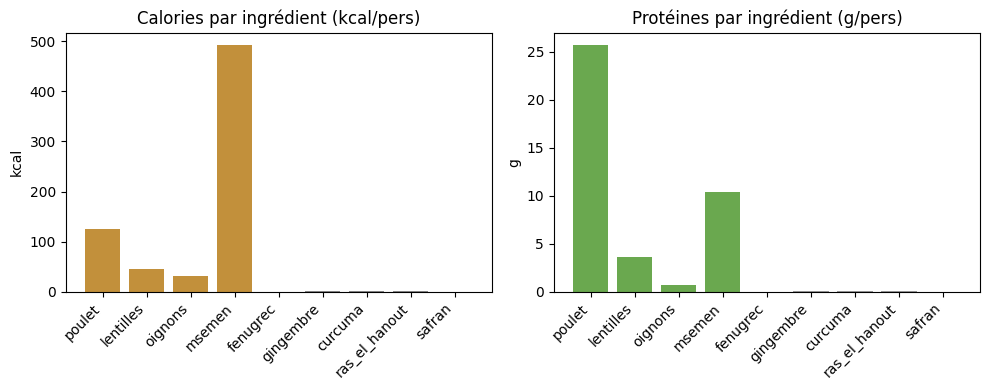

In [7]:

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.bar(df["ingrédient"], df["kcal"], color=["#c2903b" if r=="principal" else "#888888" for r in df["rôle"]])
plt.title("Calories par ingrédient (kcal/pers)")
plt.xticks(rotation=45, ha="right")
plt.ylabel("kcal")
plt.subplot(1,2,2)
plt.bar(df["ingrédient"], df["prot(g)"] , color=["#6aa84f" if r=="principal" else "#999999" for r in df["rôle"]])
plt.title("Protéines par ingrédient (g/pers)")
plt.xticks(rotation=45, ha="right")
plt.ylabel("g")
plt.tight_layout()
plt.show()



## Mise à l'échelle pour$$N$$personnes
Saisissez $$N$$ et calculez la **liste de courses** totale.


In [8]:

N = 6
df_total = df.copy()
df_total["g total"] = df_total["g/pers"]*N
print(f"Nombre de personnes: {N}")
print(df_total[["ingrédient","g total","coût(DH)"]].round(2))
print(f"Coût total ≈ {df_total['coût(DH)'].sum()*N:.2f} DH")


Nombre de personnes: 6
      ingrédient  g total  coût(DH)
0         poulet   480.00      1.96
1      lentilles   240.00      0.72
2        oignons   440.85      0.44
3         msemen   894.69      4.47
4       fenugrec     0.00      0.00
5      gingembre     3.00      0.06
6        curcuma     3.00      0.06
7  ras_el_hanout     3.00      0.08
8         safran     0.00      0.00
Coût total ≈ 46.74 DH



## Analyse de sensibilité
Changez $$C^*$$ et $$P^*$$ et résolvez à nouveau.


In [9]:

def run_with_targets(cal_star=700.0, prot_star=35.0):
    global CAL_TARGET, PROT_TARGET
    CAL_TARGET, PROT_TARGET = cal_star, prot_star
    res2 = minimize(objective, res.x, method="SLSQP", bounds=BOUNDS, constraints=CONS, options={"maxiter": 500, "ftol": 1e-9})
    d2 = vect_to_dict(res2.x)
    return d2, calories(res2.x), proteins(res2.x), cost_dh(res2.x), res2.success

d2, c2, p2, co2, ok2 = run_with_targets(650, 32)
print("Cibles: 650 kcal & 32 g prot.")
print({k: round(v,2) for k,v in d2.items()})
print(f"Total: {c2:.1f} kcal | {p2:.1f} g | coût ≈ {co2:.2f} DH | ok={ok2}")


Cibles: 650 kcal & 32 g prot.
{'poulet': 80.0, 'lentilles': 40.0, 'oignons': 72.95, 'msemen': 134.02, 'fenugrec': 0.0, 'gingembre': 0.5, 'curcuma': 0.5, 'ras_el_hanout': 0.5, 'safran': 0.0}
Total: 649.8 kcal | 39.5 g | coût ≈ 7.33 DH | ok=True



---
### Notes & limites
- Les prix en DH/kg sont **indicatifs**. Remplacez par vos prix réels.
- Les valeurs nutritionnelles sont des **moyennes**; ajustez selon vos sources laboratoires si besoin.
- Les pénalités culinaires reproduisent l'esprit de la rfissa; adaptez à vos préférences.

